In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

#Token Embedding
- Converts tokens to vectors

#Positional Encoding
- Add order info

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        print(pe)
        position = torch.arange(0, max_len).unsqueeze(1)
        print(position)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        print(div_term)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [3]:
def embedding_layer(batch, vocab, d_model):
  layer = nn.Embedding(len(vocab), d_model)
  tokens = torch.tensor([0,1,2,3,4])
  if batch is True:
    return layer(tokens.unsqueeze(0))
  return layer(tokens)


In [4]:
def visualize_embeddings(embeddings):
  pca = PCA(n_components=2)
  embedded_2d = pca.fit_transform(embeddings.detach().numpy())

  # Plot the 2D embeddings
  plt.style.use('seaborn-v0_8')
  plt.figure(figsize=(8, 6))
  for i, token in enumerate(vocab):
      x, y = embedded_2d[i]
      plt.scatter(x, y, label=token)
      plt.text(x + 0.02, y + 0.02, token)

  plt.title('2D PCA of Token Embeddings')
  plt.xlabel('PCA Component 1')
  plt.ylabel('PCA Component 2')
  plt.grid(True)
  plt.show()

#Settings

In [5]:
vocab  = {
    'dragon': 0,
    '🧠': 1,
    'fire': 2,
    'payload': 3,
    '<PAD>':4
}

##visualizing token embeddings

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


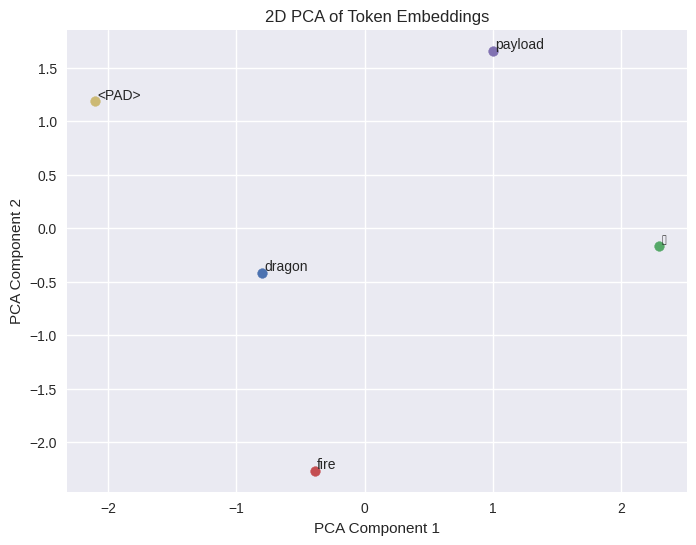

In [6]:
d_model = 10
embedded = embedding_layer(False, vocab, d_model)
visualize_embeddings(embedded)

In [7]:
embeddings  = embedding_layer(True, vocab, d_model)
pos_encoding = PositionalEncoding(d_model)
#x = pos_encoding(embeddings)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[   0],
        [   1],
        [   2],
        ...,
        [4997],
        [4998],
        [4999]])
tensor([1.0000e+00, 1.5849e-01, 2.5119e-02, 3.9811e-03, 6.3096e-04])


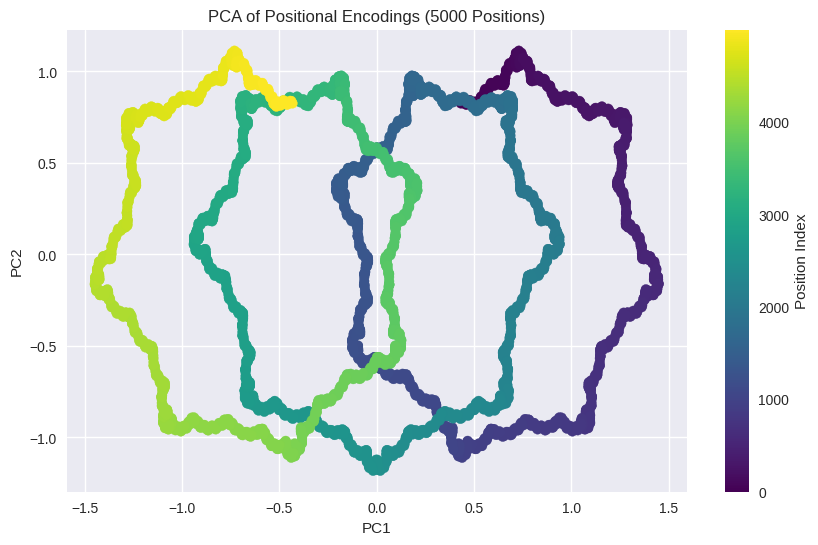

In [14]:
pe_matrix = pos_encoding.pe[0][:5000-1]
pca = PCA(n_components=2)
pe_2d = pca.fit_transform(pe_matrix)

# Plot
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pe_2d[:, 0], pe_2d[:, 1], c=range(5000-1), cmap='viridis')
plt.colorbar(scatter, label='Position Index')
plt.title('PCA of Positional Encodings (5000 Positions)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

#Multi-Head Self-Attention
- Captures relationships between tokens

#FeedForward Network
- Adds depth and non-linearity

#Layer Normalization + Residuals
-Stabilizes training

#Stacked Encoder Layer
-Builds abstraction